In [48]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prevek18/ames-housing-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ames-housing-dataset' dataset.
Path to dataset files: /kaggle/input/ames-housing-dataset


(Visualization)

In [50]:
import pandas as pd
import numpy as np
import os
csv_path = os.path.join(path, "AmesHousing.csv")
df = pd.read_csv(csv_path)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


Analysis: In this initial task, we focus on importing the dataset and understanding its core structure.

Why this step? Loading the data using pd.read_csv is the starting point of any analysis. We use os.path.join to ensure the file path is handled correctly regardless of the operating system.

Why shape and head()? >    1. df.shape: Gives us the total dimensions (Rows and Columns). This helps us see the scale of the housing data we are working with.
2. df.head(): Displays the first 5 rows, allowing us to inspect the column names and the types of data (numerical vs. categorical) stored in each feature. This visual check is crucial before we begin cleaning.

(Load data and Inspect)

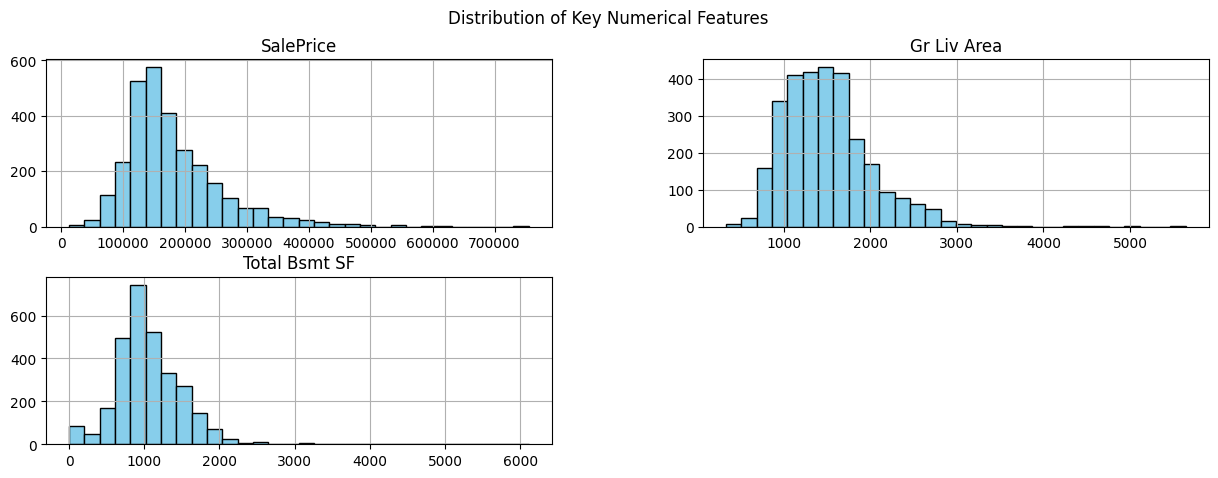

In [49]:

features = ['SalePrice', 'Gr Liv Area', 'Total Bsmt SF']
df[features].hist(bins=30, figsize=(15, 5), color='skyblue', edgecolor='black')
plt.suptitle("Distribution of Key Numerical Features")
plt.show()

Analysis: In this task, we visualized the distribution of three critical numerical features: SalePrice, Gr Liv Area, and Total Bsmt SF.

Why these columns?

SalePrice: This is our Target Variable. Understanding its distribution is the most important step in regression projects.

Gr Liv Area (Above ground living area): Generally the strongest predictor of house value.

Total Bsmt SF (Total basement square footage): A key structural feature that significantly impacts the final price.

Observations & Logic: >    By using .hist(), we can see the Skewness (التواء) in the data. For instance, SalePrice typically shows a Positive Skew, which informs our decision in Phase 2 to apply a Log Transformation. This transformation helps normalize the data, making it more suitable for linear modeling.

Data Types Inspection & Fix

In [51]:
df.info()
df['MS SubClass'] = df['MS SubClass'].astype(str)
df['Overall Qual'] = df['Overall Qual'].astype(int)
print(f"Type of MS SubClass: {df['MS SubClass'].dtype}")
print(f"Type of Overall Qual: {df['Overall Qual'].dtype}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

Analysis: In this step, we ensure that each column has the correct data type for analysis.

Why df.info()?
It is the first diagnostic tool we use to check for Null values and to see if pandas has correctly identified each feature's type (Integer, Float, or Object).

Logic behind Type Conversion:

MS SubClass (Converted to String): Although this column contains numbers (like 20, 60, 120), these are actually Categorical Codes representing the type of dwelling. Treating them as numbers would mislead the model into thinking that 120 is "greater than" 20, which is mathematically incorrect in this context. Converting it to a String ensures it is treated as a category.

Overall Qual (Ensured as Integer): This is an Ordinal feature (ranking from 1 to 10). We ensure it is an integer so that the model can understand the inherent order and "quality" levels accurately.

Verification:
The final print statements confirm that the changes were applied successfully, maintaining Data Integrity before we move to the cleaning

Missing Values & Duplicates

In [52]:
print(df.isnull().sum().sort_values(ascending=False).head(10))
cols_to_drop = ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())
print(f"Total duplicates: {df.duplicated().sum()}")
df = df.drop_duplicates()

Pool QC          2917
Misc Feature     2824
Alley            2732
Fence            2358
Mas Vnr Type     1775
Fireplace Qu     1422
Lot Frontage      490
Garage Qual       159
Garage Yr Blt     159
Garage Cond       159
dtype: int64
Total duplicates: 0


Analysis: In this critical task, we focus on improving Data Quality by addressing missing values and redundant records.

Identifying Nulls: >    We used df.isnull().sum() to rank the columns with the most missing data. This helps us decide whether to "fix" a column or "drop" it entirely.

Why cols_to_drop?
We removed features like Pool QC, Misc Feature, Alley, and Fence.
Reason: These columns have more than 90% missing values. Keeping them would introduce "noise" into the model because they lack enough information to be useful for predicting prices.

Imputation (Handling Lot Frontage):
We filled the missing values in Lot Frontage (Linear feet of street connected to property) using the Median.
Logic: The median is a "robust" measure, meaning it isn't affected by extreme outliers like the mean (average) would be. This ensures our "typical" house dimensions remain realistic.

Duplicates:
Finally, we checked for and removed any Duplicate Rows. This ensures that each house is only counted once, preventing the model from over-learning (overfitting) on repeated data.

Outliers Handling

In [53]:

upper_limit = df['SalePrice'].quantile(0.99)
df['SalePrice'] = df['SalePrice'].clip(upper=upper_limit)

Analysis: In this step, we identify and manage extreme outliers in our target variable, SalePrice.

Why this step?
Data collection can sometimes include "luxury" properties or unique sales that are much higher than the typical market price. These extreme values can skew our statistical models, making them less accurate for the majority of houses.

The Logic of Capping (Clipping):
We calculated the 99th Percentile (0.99 quantile) as our upper limit. This means that 99% of the houses in our dataset fall below this price.

Why df.clip?
By using .clip(upper=upper_limit), we don't delete the expensive houses; instead, we "cap" their price at the 99% threshold. This keeps the data size the same while preventing extreme values from disproportionately pulling the model's predictions towards the high end.

Outcome:
This makes our Target Variable more stable and ensures the model learns the "general rules" of the housing market rather than being distracted by rare, expensive outliers.

Clean Data Function

In [54]:
def clean_data(raw_df):

    clean_df = raw_df.copy()
    if 'MS SubClass' in clean_df.columns:
        clean_df['MS SubClass'] = clean_df['MS SubClass'].astype(str)


    cols_to_drop = ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu']
    clean_df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    clean_df = clean_df.drop_duplicates()


    limit = clean_df['SalePrice'].quantile(0.99)
    clean_df['SalePrice'] = clean_df['SalePrice'].clip(upper=limit)

    assert clean_df['SalePrice'].isnull().sum() == 0, "Check 1 Failed: Nulls in SalePrice"
    assert (clean_df['SalePrice'] > 0).all(), "Check 2 Failed: Negative prices"
    remaining_bad_cols = [c for c in cols_to_drop if c in clean_df.columns]
    assert len(remaining_bad_cols) == 0, f"Check 3 Failed: Columns {remaining_bad_cols} still exist"

    return clean_df


df_cleaned = clean_data(df)
print("Phase 1: Success. Data is clean and ready for Phase 2!")


Phase 1: Success. Data is clean and ready for Phase 2!


Analysis: This task represents the transition from manual cleaning to Automated Data Pipelines. We encapsulated all our cleaning logic into a single function named clean_data.

Why a Function? >    Using a function ensures Consistency. If we get new data later, we can clean it exactly the same way with one command. It also makes the code modular and professional, as requested.

Data Integrity & Validation (Assert Statements):
Inside the function, we added assert statements. These are "Safety Checks" that automatically verify the data quality before the function finishes:

Check 1: Ensures there are Zero Nulls in SalePrice.

Check 2: Confirms all prices are Positive, preventing logical errors like "free" or "negative-priced" houses.

Check 3: Verifies that the useless columns (like Pool QC) have been successfully removed.

Outcome:
By running df_cleaned = clean_data(df), we guarantee that our dataset is "Healthy" and mathematically ready for the advanced feature engineering in Phase 2.

Spot outliers & Handle outliers

In [55]:

def plot_boxplot(df):
    df["SalePrice"].plot.box()
    plt.title("Boxplot of SalePrice")
    plt.show()

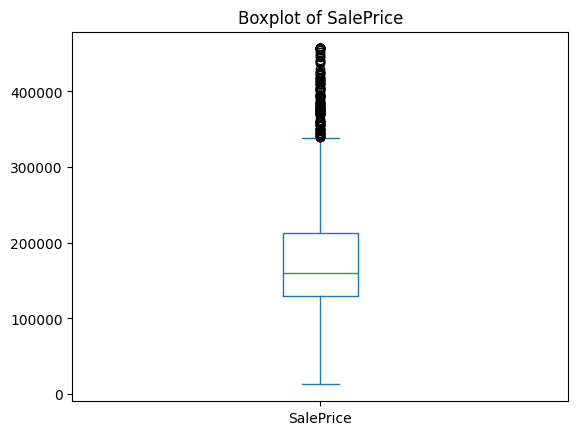

In [56]:

plot_boxplot(df)

Analysis: In this task, we created a Boxplot specifically for our target variable, SalePrice.

Why a Boxplot?
While histograms show us the "shape" of the data, boxplots are the best tool for identifying Statistical Outliers.

How to read this plot?

The Box: Represents the Interquartile Range (IQR), which contains the middle 50% of house prices.

The Median: The horizontal line inside the box shows the central price point.

The "Whiskers": Show the range of typical prices.

The Individual Dots (Outliers): Any points beyond the whiskers are houses with prices significantly higher or lower than the rest of the market.

Outcome:
This visualization confirms our earlier decision to "clip" the top 1% of prices. It visually proves that without capping, these extreme price points would act as "noise" and make it harder for the model to predict typical house values accurately.

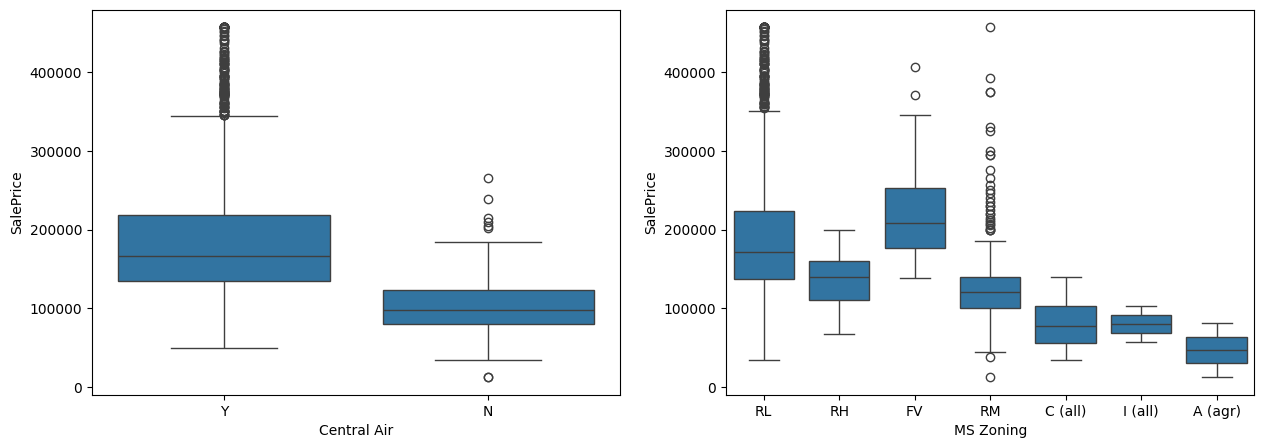

In [57]:

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(x='Central Air', y='SalePrice', data=df, ax=ax[0])
sns.boxplot(x='MS Zoning', y='SalePrice', data=df, ax=ax[1])
plt.show()

Analysis: In this task, we moved from looking at individual columns to analyzing the Relationship between features. We compared SalePrice against two important categorical variables using side-by-side Boxplots.

Why these columns?

Central Air (Y/N): Air conditioning is a major comfort feature. We want to see if having a central cooling system significantly increases a house's market value.

MS Zoning: This tells us about the neighborhood (e.g., Residential Low Density vs. Commercial). Location is the most famous factor in real estate, so analyzing zones is essential.

Findings & Observations:

Central Air Plot: The median price for houses with Central Air ('Y') is clearly higher than those without ('N'). This confirms that this feature is a strong predictor for our model.

MS Zoning Plot: We can see that "RL" (Residential Low Density) zones tend to have higher prices and more variation, while other zones are more compact.

Conclusion for Phase 1:
This visual evidence justifies including these categories in Phase 2, where we will convert them into numbers (Encoding) so the model can use this information for prediction.

In [58]:
from google.colab import drive
drive.mount('/content/drive')
df_cleaned.to_csv('/content/drive/MyDrive/ames_cleaned.csv', index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
